In [8]:
from multiprocessing import current_process
from netgen.meshing import *
from netgen.csg import *
from netgen.occ import *
from ngsolve import *
from ngsolve.webgui import Draw
from netgen.webgui import Draw as DrawGeo
import math
from numpy import *
import scipy.sparse as sp
import matplotlib.pylab as plt
from scipy.io import savemat
import scipy.sparse as sp


In [9]:
import os, sys
sys.path.append('../../ICCG/JP-MARs/SparseSolv')
import SparseSolvPy

In [10]:
h=0.01
r=0.01
conductor = Cylinder((0,0,0), Z, r=r, h=h)
conductor.maxh=r/10.
Draw(conductor)

conductor.faces.name="conductorBND"
conductor.faces.Max(Z).name="out"
conductor.faces.Min(Z).name="in"
conductor.mat("sig")
crosssection = conductor.faces.Max(Z).mass
print(crosssection)

geo =OCCGeometry(conductor)
with TaskManager():
#    mesh = Mesh(geo.GenerateMesh(maxh=0.005)).Curve(3)
#    mesh = Mesh(geo.GenerateMesh(maxh=0.001)).Curve(100)  
    #mesh = Mesh(geo.GenerateMesh()).Curve(0) 
    mesh = Mesh(geo.GenerateMesh(maxh=0.001)).Curve(3)
#    mesh = Mesh(geo.GenerateMesh(meshsize.very_coarse)).Curve(5)   
Draw (mesh)

WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'ngsolve_version': 'Netgen x.x', 'mesh_dim': 3…

0.0003141592653589792


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.24…

BaseWebGuiScene

In [15]:
order=1
fesA = HCurl(mesh, order=order, nograds=True, dirichlet="in|out|conductorBND", complex=False)
print ("nograds=T_ndof =", fesA.ndof)
fesA = HCurl(mesh, order=order, nograds=False, dirichlet="in|out|conductorBND", complex=False)
print ("nograds=F_ndof =", fesA.ndof)

fesA = HCurl(mesh, order=order, type1=True, dirichlet="in|out|conductorBND", complex=False)
print ("Type1=T_ndof =", fesA.ndof)
fesA = HCurl(mesh, order=order, type1=False, dirichlet="in|out|conductorBND", complex=False)
print ("Type1=F_ndof =", fesA.ndof)

fesA = HCurl(mesh, order=order, type2=True, dirichlet="in|out|conductorBND", complex=False)
print ("Type2=T_ndof =", fesA.ndof)
fesA = HCurl(mesh, order=order, type2=False, dirichlet="in|out|conductorBND", complex=False)
print ("Type2=F_ndof =", fesA.ndof)


nograds=T_ndof = 17754
nograds=F_ndof = 35508
Type1=T_ndof = 17754
Type1=F_ndof = 35508
Type2=T_ndof = 35508
Type2=F_ndof = 35508


In [4]:
edges_no=mesh.nedge
faces_no=mesh.nface
elements_no=mesh.nv
calcd_ndof = (mesh.nv*4)+( mesh.nedge*6)
print('#nv=', mesh.nv)
print('#nedge=', mesh.nedge)
print('#nface=', mesh.nface)
print('#ne=', mesh.ne)
print(calcd_ndof)
order=1
#fesA = HCurl(mesh, order=order, nograds=True, dirichlet="in|out|conductorBND", complex=False)
fesA = HCurl(mesh, order=order, nograds=False, dirichlet="in|out|conductorBND", complex=False)
fesPhi = H1(mesh,  order=order, definedon="sig", dirichlet="in|out", complex=False)
print ("Hcurl_ndof =", fesA.ndof)
print ("H1_ndof =", fesPhi.ndof)
print ("ndof =", fesA.ndof+fesPhi.ndof)

A, N =fesA.TnT()
phi, psi =fesPhi.TnT()

c = 299792458.
mu = 4*math.pi*1e-7
eps = 1/(c*c*mu)
sigma=1e6

Rn=[]
Ln=[]
log1min=[]
ndof=[]
nstage=[]

#E = CoefficientFunction((0,0,1))
#J = sigma*E

#nv= 2971
#nedge= 17754
#nface= 28197
#ne= 13413
118408
Hcurl_ndof = 35508
H1_ndof = 2971
ndof = 38479


In [5]:
a=BilinearForm(fesPhi)
a += sigma*grad(phi)*grad(psi)*dx

with TaskManager():
    a.Assemble()
gfPhi = GridFunction(fesPhi)
gfPhi.Set(h, definedon=mesh.Boundaries("in"))
f=LinearForm(fesPhi)
f.Assemble()
fr=f.vec-a.mat*gfPhi.vec

import scipy.sparse as sp
asci = sp.csr_matrix (a.mat.CSR())
Acut = asci[:,fesPhi.FreeDofs()][fesPhi.FreeDofs(),:]
fcut = array(fr.Evaluate())[fesPhi.FreeDofs()]
ucut = array(fr.Evaluate(), copy=True)[fesPhi.FreeDofs()]
rows, cols = Acut.nonzero()
vals = Acut[rows, cols]
vals = ravel(vals)
dim=fcut.size
size= (len(rows)-dim)/2-dim
print('Dof=',dim, '   matrix size=', size)

Dof= 2234    matrix size= 11115.0


<ufunc 'log'>


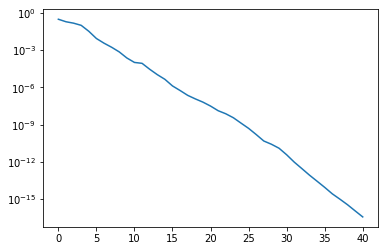

min: 3.844291108142674e-17
結果のノルム: 2.3076594356801644e-15


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.24…

WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.24…

BaseWebGuiScene

In [6]:
mat = SparseSolvPy.SparseMat(len(rows), rows, cols, vals)

solver = SparseSolvPy.MatSolvers()
solver.setSaveBest(True)
solver.setSaveLog(True)
solver.setDiagScale(False)
solver.setDirvegeType(1)
solver.setBadDivCount(10)
solver.setBadDivVal(10.0)
tol=1.e-16
max_iter=200
solver.solveICCG_py(len(fcut), tol, max_iter, 1.0, mat, fcut, ucut, True)

log1 = solver.getResidualLog_py()
print(log)

plt.plot(range(len(log1)), log1)    
plt.yscale('log')
plt.show(block=False)  

array(gfPhi.vec.FV(), copy=False)[fesPhi.FreeDofs()] = ucut
print("min:", min(log1))
#log1min.append(min(log1))

result = Acut.dot(ucut) - fcut
norm = linalg.norm(result)/linalg.norm(fcut)
print("結果のノルム:", norm)

Draw(gfPhi,mesh)
Draw(grad(gfPhi)*sigma,mesh)

In [7]:
E=-grad(gfPhi)
J=sigma*E

nStage=0
R = 1/Integrate(sigma*E*E*dx, mesh)
Rn.append(R)
R_theory = (2*nStage+1)/(pi*r*r*sigma*h)
print("R_theory[",2*nStage,"]:", R_theory)
print("       R[",2*nStage,"]:", R)
R_err = abs(R - R_theory)/abs(R_theory)
print("     R_err[",nStage+1,"]:",R_err) 

R_theory[ 0 ]: 0.3183098861837906
       R[ 0 ]: 0.3183098645130293
     R_err[ 1 ]: 6.808070448695519e-08


In [8]:
Draw(J,mesh)

WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.24…

BaseWebGuiScene

In [ ]:
for nStage in range(1):
    print(nStage+1, "-stage")
    nstage.append(nStage+1)

    a = BilinearForm(fesA)
    a += 1/mu*curl(A)*curl(N)*dx
    f = LinearForm(fesA)
    f += N*(R*J) * dx
    with TaskManager():
        a.Assemble()
        f.Assemble()

    gfA = GridFunction(fesA)
    #Draw(gfA,mesh)
    
    mat = sp.csr_matrix (a.mat.CSR())
    
    print(mat)
    
    Acut = mat[:,fesA.FreeDofs()][fesA.FreeDofs(),:]
    print("Acut",Acut)
    
    fcut = array(f.vec.FV())[fesA.FreeDofs()]
    print("fcut",fcut)
    print("f.vec.FV",f.vec.FV())
    
    
    print(f'fcutlen={len(f.vec.FV())}')
    print(f'sumAfreedofs={sum(fesA.FreeDofs())}')
    
    
    ucut = array(f.vec.FV(), copy=True)[fesA.FreeDofs()]
    print("ucut",ucut)

    rows, cols = Acut.nonzero()
    vals = Acut[rows, cols]
    vals = ravel(vals)
    dim=fcut.size
    size= (len(rows)-dim)/2-dim
    print('Dof=',dim, '   matrix size=', size)
    
    mat = SparseSolvPy.SparseMat(len(rows), rows, cols, vals)

    
    solver = SparseSolvPy.MatSolvers()
    solver.setSaveBest(True)
    solver.setSaveLog(True)
    solver.setDiagScale(False)
    solver.setDirvegeType(1)
    solver.setBadDivCount(10)
    solver.setBadDivVal(10.0)
    tol=1.e-16
    max_iter=200
    solver.solveICCG_py(len(fcut), tol, max_iter, 1.1, mat, fcut, ucut, True)
    
    
    log1 = solver.getResidualLog_py()
    #print(log1)

    plt.plot(range(len(log1)), log1)    
    plt.yscale('log')
    plt.show(block=False)  
    
    array(gfA.vec.FV(), copy=False)[fesA.FreeDofs()] = ucut
    print("min:", min(log1))
    #log1min.append(min(log1))

    result = Acut.dot(ucut) - fcut
    norm = linalg.norm(result)/linalg.norm(fcut)
    print("結果のノルム:", norm)
    
    if nStage ==0:
        Apot=gfA
        B= curl(gfA)
    else:
        Apot =Apot + gfA
        B = B+curl(gfA)

    #B=curl(Apot)
    L = Integrate(B*B/mu*dx, mesh)
    Ln.append(L)
    L_theory = (mu)/(4*2*(nStage+1)*pi*h)
    print("L_theory[",2*nStage+1,"]:", L_theory)
    print("       L[",2*nStage+1,"]:", L)
    L_err = abs(L - L_theory)/abs(L_theory)
    print("     L_err[",nStage+1,"]:",L_err) 
    
    a = BilinearForm(fesPhi)
    a += sigma*grad(phi)*grad(psi)*dx
    f = LinearForm(fesPhi)
    f += sigma*grad(psi)*(-Apot/L) * dx
    with TaskManager():
        a.Assemble()
        f.Assemble()

    gfPhi = GridFunction(fesPhi)

    mat = sp.csr_matrix (a.mat.CSR())
    #print(mat)
    Acut = mat[:,fesPhi.FreeDofs()][fesPhi.FreeDofs(),:]
    fcut = array(f.vec.FV())[fesPhi.FreeDofs()]
    ucut = array(f.vec.FV(), copy=True)[fesPhi.FreeDofs()]

    rows, cols = Acut.nonzero()
    vals = Acut[rows, cols]
    vals = ravel(vals)
    dim=fcut.size
    size= (len(rows)-dim)/2-dim
    print('Dof=',dim, '   matrix size=', size)

    mat = SparseSolvPy.SparseMat(len(rows), rows, cols, vals)

    solver = SparseSolvPy.MatSolvers()
    solver.setSaveBest(True)
    solver.setSaveLog(True)
    solver.setDiagScale(False)
    solver.setDirvegeType(1)
    solver.setBadDivCount(10)
    solver.setBadDivVal(10.0)
    tol=1.e-16
    max_iter=200
    solver.solveICCG_py(len(fcut), tol, max_iter, 1.0, mat, fcut, ucut, True)

    log1 = solver.getResidualLog_py()
    #print(log1)

    plt.plot(range(len(log1)), log1)    
    plt.yscale('log')
    plt.show(block=False)  

    array(gfPhi.vec.FV(), copy=False)[fesPhi.FreeDofs()] = ucut
    print("min:", min(log1))
    #log1min.append(min(log1))

    result = Acut.dot(ucut) - fcut
    norm = linalg.norm(result)/linalg.norm(fcut)
    print("結果のノルム:", norm)

    result = Acut.dot(ucut) - fcut
    norm = linalg.norm(result)/linalg.norm(fcut)
    print("norm=", norm)

    E =E -Apot/L-grad(gfPhi)
    J= sigma*E

    R = 1/Integrate(sigma*E*E*dx, mesh)
    
    if nStage<10-1:
        Rn.append(R)
       
    R_theory = (2*nStage+3)/(pi*r*r*sigma*h)
    print("R_theory[",2*nStage+2,"]:", R_theory)
    print("       R[",2*nStage+2,"]:", R)
    R_err = abs(R - R_theory)/abs(R_theory)
    print("     R_err[",nStage+2,"]:",R_err) 

data = {'Rn': Rn, 'Ln': Ln}
FileName = f"Aphi_{order}.mat"  
savemat(FileName,data) 


1 -stage
  (0, 0)	1103533255.1013515
  (0, 2)	-392199768.80165285
  (0, 4)	-711333486.2996988
  (0, 12)	538030045.6683079
  (0, 14)	565503209.4330437
  (0, 384)	145830276.8666551
  (0, 17754)	0.0
  (0, 17756)	0.0
  (0, 17758)	0.0
  (0, 17766)	0.0
  (0, 17768)	0.0
  (0, 18138)	0.0
  (1, 1)	1212505457.0663998
  (1, 3)	-680829349.5640877
  (1, 5)	-531676107.5023121
  (1, 313)	1007090183.7584522
  (1, 314)	205415273.30794773
  (1, 1107)	326260834.1943644
  (1, 17755)	0.0
  (1, 17757)	0.0
  (1, 17759)	0.0
  (1, 18067)	0.0
  (1, 18068)	0.0
  (1, 18861)	0.0
  (2, 0)	-392199768.80165285
  :	:
  (35507, 16224)	0.0
  (35507, 16225)	0.0
  (35507, 16226)	0.0
  (35507, 16227)	0.0
  (35507, 17738)	0.0
  (35507, 17739)	0.0
  (35507, 17742)	0.0
  (35507, 17743)	0.0
  (35507, 17753)	0.0
  (35507, 33213)	0.0
  (35507, 33221)	0.0
  (35507, 33222)	0.0
  (35507, 33223)	0.0
  (35507, 33456)	0.0
  (35507, 33457)	0.0
  (35507, 33458)	0.0
  (35507, 33978)	0.0
  (35507, 33979)	0.0
  (35507, 33980)	0.0
  (35507,